In [1]:
# 16일차 폴더에 있는 성적 데이터를 이용하여 예측하는 예제
# 데이터 생성
import pandas as pd
import tensorflow as tf

df = pd.read_csv('../day16(dl)/성적데이터.csv')

In [2]:
# 독립, 종속 분리
X = df.iloc[: , :-1]
y = df.iloc[:, -1]

In [3]:
# 원핫인코딩 => 범주형 데이터를 수치로 변환 
# 8일차 05_다중선형회귀2에서 참고
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(drop='first'), [2])], remainder='passthrough')
X = ct.fit_transform(X)

In [4]:
# 학습, 훈련 분리 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# 정규화
from tensorflow.keras import layers, models
import numpy as np

nomalizer = layers.Normalization(axis=-1)
nomalizer.adapt(np.array(X_train))

In [6]:
# 모델 설계
model = models.Sequential([
	nomalizer, 
	layers.Dense(64, activation='relu'),
	layers.Dense(32, activation='relu'),
	layers.Dense(16, activation='relu'),
	layers.Dense(1, activation='linear') # 출력층
])

In [7]:
# 모델 설정
model.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

dataset = dataset.batch(50).prefetch(tf.data.AUTOTUNE)


In [9]:
# 학습
history = model.fit(dataset, epochs=1000, batch_size=50, verbose=0)
# 학습 시간 : 45.2s(일반)
# 학습 시간 : 9.9s(파이프라인)

dict_keys(['loss', 'mae'])


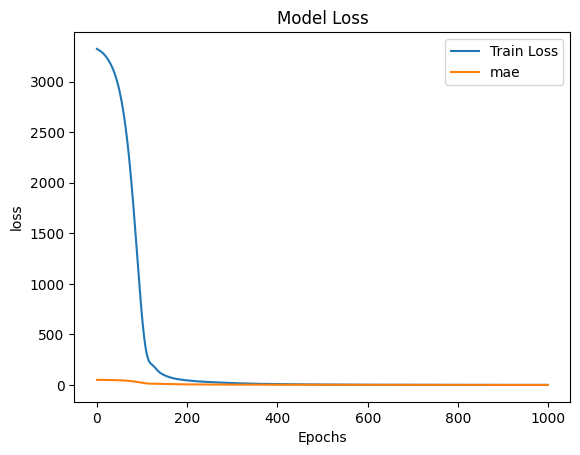

In [14]:
import matplotlib.pyplot as plt
print(history.history.keys())
plt.plot(history.history['loss'], label='Train Loss')
# model.fit에 validation_split이 없으면 val_loss, val_accuracy도 없음
# plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['mae'], label='mae')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [11]:
# 평가
import tensorflow as tf
test_loss , test_acc = model.evaluate(X_test, y_test)
print(f'절대값 오차 평균: { tf.sqrt(test_loss):.1f}')
predictions = model.predict(np.array(X_test))

size = y_test.size

for i in range(size):
	print(f'예측값 : {predictions[i][0]:.1f}, 실제값 : {y_test.values[i]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 7.5384 - mae: 2.3960
절대값 오차 평균: 2.7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
예측값 : 22.5, 실제값 : 22
예측값 : 80.3, 실제값 : 76
예측값 : 57.3, 실제값 : 60
예측값 : 69.9, 실제값 : 72


In [12]:
# 예측
# 집에서 5시간공부하고 결석 0
# 도서관에서 5시간 공부하고 결석 0
# 집에서 7시간 공부하고 결석 3
# 카페에서 6시간 공부하고 결석 2
# 원핫인코딩으로 X_test를 변환
new_dataset = [
	[5,0, 'Home'],
	[5,0, 'Library'],
	[7,3, 'Home'], 
	[7,0, 'Home'],
	[9,0, 'Home'],
]
# fit_transform : 학습 시키고 변환
# transform : 이전에 학습된 값을 기준으로 변환
new_dataset_encodng = ct.transform(new_dataset)
print(new_dataset_encodng)
predictions2 = model.predict(np.array(new_dataset_encodng, 'float32'))
for i in range(5):
	print(f'학습시간 : {new_dataset[i][0]}, ' 
			 + f'장소 : {new_dataset[i][2]}, '
			 + f'결석 :{new_dataset[i][1]}, ' 
			 + f'예측 성적 : {predictions2[i][0]}')

[[1.0 0.0 5 0]
 [0.0 1.0 5 0]
 [1.0 0.0 7 3]
 [1.0 0.0 7 0]
 [1.0 0.0 9 0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
학습시간 : 5, 장소 : Home, 결석 :0, 예측 성적 : 45.918426513671875
학습시간 : 5, 장소 : Library, 결석 :0, 예측 성적 : 56.63348388671875
학습시간 : 7, 장소 : Home, 결석 :3, 예측 성적 : 59.321372985839844
학습시간 : 7, 장소 : Home, 결석 :0, 예측 성적 : 69.75982666015625
학습시간 : 9, 장소 : Home, 결석 :0, 예측 성적 : 94.8389663696289


c:\Users\hi6\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
